# 🧬 Algoritmo Genético – Optimización de Función

Este proyecto implementa un **algoritmo genético** básico en Python para optimizar una función matemática (por ejemplo, maximizar `f(x)` en un dominio dado).  
El objetivo es simular los procesos de **evolución biológica**: selección, reproducción, mutación y reemplazo de generaciones.

---

## ⚙️ Descripción general

- **Representación de individuos:** cada individuo es una lista de dígitos decimales que representan un número entre `0.0` y `1.99999999999`.  
- **Fitness:** mide qué tan buena es una solución dentro de la población (qué tan alto es su valor de `f(x)`).
- **Selección:** los individuos con mayor fitness tienen más probabilidades de reproducirse.
- **Reproducción (crossover):** se combinan los genes de dos padres para generar nuevos individuos (hijos).
- **Mutación:** con baja probabilidad, se altera un gen aleatoriamente para mantener diversidad genética.
- **Iteraciones:** se repite el proceso durante varias generaciones hasta que la población converge a una solución óptima.

---

## 📦 Dependencias

```bash
pip install numpy matplotlib


In [3]:
# Ejemplo extraido del libro "Algoritmos genéticos con Python" de Daniel Gutiérrez Reina y otros
# https://alfaomegaeditor.com.ar/producto/libros-algoritmos-geneticos-con-python/
# https://baobabsoluciones.es/blog/2020/10/01/problema-del-viajante/
# https://towardsdatascience.com/solving-geographic-travelling-salesman-problems-using-python-e57284b14cd7
# https://codingornot.com/08-agente-viajero-algoritmo-genetico
# https://deap.readthedocs.io/en/master/

!pip install deap
import random
import json
import numpy
import matplotlib.pyplot as plt
from deap import algorithms
from deap import base
from deap import creator
from deap import tools

In [4]:
url='https://github.com/palasatenea66/DATASETS/raw/main/gr120.json'
!wget $url

zsh:1: command not found: wget


In [5]:
!ls

AG_TSP_CON_DEAP.ipynb gr17.json
gr120.json            gr24.json


In [6]:
# gr*.json contiene el mapa de distancias entre ciudades en formato JSON
with open("gr120.json", "r") as tsp_data:
    tsp = json.load(tsp_data)


In [7]:
tsp

{'TourSize': 120,
 'OptTour': [1,
  76,
  59,
  15,
  30,
  29,
  120,
  32,
  92,
  28,
  45,
  78,
  86,
  94,
  81,
  22,
  66,
  31,
  117,
  85,
  18,
  19,
  25,
  108,
  43,
  79,
  52,
  33,
  100,
  58,
  91,
  68,
  65,
  69,
  113,
  107,
  20,
  46,
  50,
  44,
  75,
  14,
  87,
  74,
  105,
  40,
  72,
  38,
  7,
  56,
  41,
  42,
  98,
  17,
  118,
  49,
  13,
  51,
  11,
  23,
  9,
  103,
  119,
  3,
  82,
  2,
  115,
  21,
  93,
  53,
  64,
  109,
  88,
  97,
  12,
  95,
  77,
  39,
  63,
  5,
  27,
  80,
  101,
  102,
  48,
  110,
  112,
  106,
  114,
  73,
  57,
  83,
  67,
  37,
  62,
  99,
  10,
  35,
  104,
  36,
  84,
  6,
  89,
  55,
  47,
  71,
  26,
  4,
  34,
  116,
  70,
  8,
  54,
  90,
  96,
  111,
  24,
  60,
  16,
  61],
 'OptDistance': 6942,
 'DistanceMatrix': [[0,
   534,
   434,
   294,
   593,
   409,
   332,
   232,
   464,
   566,
   552,
   802,
   633,
   257,
   187,
   91,
   412,
   400,
   472,
   389,
   610,
   340,
   510,
   153,
   511,
 

In [8]:
# matriz de distancia
distance_map = tsp["DistanceMatrix"]
# número de ciudades que visitar
IND_SIZE = tsp["TourSize"]


In [9]:
distance_map

[[0,
  534,
  434,
  294,
  593,
  409,
  332,
  232,
  464,
  566,
  552,
  802,
  633,
  257,
  187,
  91,
  412,
  400,
  472,
  389,
  610,
  340,
  510,
  153,
  511,
  269,
  525,
  150,
  80,
  130,
  401,
  134,
  666,
  259,
  505,
  453,
  627,
  339,
  710,
  243,
  376,
  449,
  505,
  322,
  185,
  353,
  324,
  388,
  447,
  360,
  605,
  656,
  573,
  293,
  372,
  330,
  610,
  598,
  214,
  154,
  70,
  606,
  631,
  642,
  503,
  372,
  641,
  561,
  478,
  247,
  317,
  272,
  575,
  219,
  293,
  54,
  648,
  211,
  568,
  497,
  290,
  475,
  654,
  445,
  375,
  268,
  261,
  710,
  396,
  295,
  651,
  175,
  585,
  250,
  717,
  246,
  788,
  426,
  596,
  634,
  507,
  463,
  408,
  529,
  192,
  529,
  434,
  535,
  630,
  446,
  166,
  471,
  442,
  523,
  566,
  235,
  432,
  435,
  369,
  121],
 [534,
  0,
  107,
  241,
  190,
  351,
  320,
  354,
  124,
  508,
  80,
  316,
  432,
  641,
  577,
  450,
  624,
  752,
  805,
  665,
  76,
  730,
  152,
  447,
 

In [10]:
IND_SIZE

120

In [11]:
def evalTSP(individual):
    """ Función objetivo, calcula la distancia que recorre el viajante"""
    # distancia entre el último elemento y el primero
    distance = distance_map[individual[-1]][individual[0]]
    # distancia entre el resto de ciudades
    for gene1, gene2 in zip(individual[0:-1], individual[1:]):
        distance += distance_map[gene1][gene2]
    return distance,


In [12]:
def plot_evolucion(log):
    gen = log.select("gen")
    fit_mins = log.select("min")
    fit_maxs = log.select("max")
    fit_ave = log.select("avg")

    fig, ax1 = plt.subplots()
    ax1.plot(gen, fit_mins, "b")
    ax1.plot(gen, fit_maxs, "r")
    ax1.plot(gen, fit_ave, "--k")
    '''
    ax1.fill_between(gen, fit_mins, fit_maxs,
                     where=fit_maxs >= fit_mins,
                     facecolor="g", alpha=0.2)'''
    ax1.set_xlabel("Generación")
    ax1.set_ylabel("Fitness")
    ax1.legend(["Min", "Max", "Avg"])
    ax1.set_ylim([5000, 50000])
    plt.grid(True)
    plt.savefig("EvolucionTSP.eps", dpi=300)

In [ ]:
def main():
    #random.seed(100)  # (opcional) fija la semilla para reproducibilidad de los resultados
    
    # Probabilidades y número de generaciones
    CXPB, MUTPB, NGEN = 0.6, 0.4, 2000  # CXPB: probabilidad de cruce, MUTPB: de mutación, NGEN: generaciones
    
    # Genera la población inicial
    pop = toolbox.population()
    
    # Parámetros de tamaño para el algoritmo (μ + λ)
    MU, LAMBDA = len(pop), len(pop)  # cantidad de padres (μ) y cantidad de hijos (λ)
    
    # Hall of Fame: guarda el mejor individuo encontrado
    hof = tools.HallOfFame(1)
    
    # Estadísticas para registrar la evolución del fitness
    stats = tools.Statistics(lambda ind: ind.fitness.values)
    stats.register("avg", numpy.mean)  # promedio
    stats.register("std", numpy.std)   # desviación estándar
    stats.register("min", numpy.min)   # valor mínimo
    stats.register("max", numpy.max)   # valor máximo
    
    # Registro del historial de la evolución (logbook)
    logbook = tools.Logbook()
    
    # Ejecuta el algoritmo genético (modelo μ + λ)
    pop, logbook = algorithms.eaMuPlusLambda(
        pop, toolbox, MU, LAMBDA,
        CXPB, MUTPB, NGEN,
        stats=stats,
        halloffame=hof
    )
    
    # Devuelve el mejor individuo (hof) y el registro de estadísticas
    return hof, logbook


In [14]:
# Creamos los objetos para definir el problema y el tipo de individuo
creator.create("FitnessMin", base.Fitness, weights=(-1.0,))
creator.create("Individual", list, fitness=creator.FitnessMin)

In [15]:
toolbox = base.Toolbox()
# Generación de un tour aleatorio
toolbox.register("indices", random.sample, range(IND_SIZE), IND_SIZE)

# Generación de inviduos y población
toolbox.register("individual", tools.initIterate, creator.Individual,
                 toolbox.indices)
toolbox.register("population", tools.initRepeat, list,
                 toolbox.individual, 100)

In [16]:
# registro de operaciones genéticas
toolbox.register("mate", tools.cxOrdered)
toolbox.register("mutate", tools.mutShuffleIndexes, indpb=0.05)
toolbox.register("select", tools.selTournament, tournsize=3)
toolbox.register("evaluate", evalTSP)


In [17]:
best, log = main()
print("Mejor fitness: %f" %best[0].fitness.values)
print("Mejor individuo %s" %best[0])


gen	nevals	avg    	std   	min  	max  
0  	100   	52298.8	2050.6	46803	57738
1  	100   	50439.9	1947.39	45573	54278
2  	100   	48767.7	1856.31	44543	52498
3  	100   	47506.8	1482.73	44543	50523
4  	100   	46380.2	1188.96	42598	49071
5  	100   	45691.1	996.567	42598	47982
6  	100   	44941.2	1083.6 	41184	48372
7  	100   	44340  	1088.11	41184	46619
8  	100   	43780.9	1149.72	41157	46775
9  	100   	42875.3	1431.48	38746	45331
10 	100   	42041.4	1546.08	38541	45113
11 	100   	41141.3	1374.27	38541	44142
12 	100   	40324.2	1224.17	38541	42613
13 	100   	39635.9	1095.52	38314	43838
14 	100   	38936.8	594.607	37661	40824
15 	100   	38654.4	432.35 	37658	40824
16 	100   	38440.7	386.992	37639	39479
17 	100   	38310.4	455.921	37376	39813
18 	100   	38048.6	485.465	36892	39906
19 	100   	37787.7	528.47 	36587	39319
20 	100   	37470.1	496.058	36587	38988
21 	100   	37194.1	424.953	36587	38309
22 	100   	36998.6	430.505	35794	38363
23 	100   	36757.7	380.824	35794	38501
24 	100   	36551.1	481.088	

In [18]:
tsp['OptTour']

[1,
 76,
 59,
 15,
 30,
 29,
 120,
 32,
 92,
 28,
 45,
 78,
 86,
 94,
 81,
 22,
 66,
 31,
 117,
 85,
 18,
 19,
 25,
 108,
 43,
 79,
 52,
 33,
 100,
 58,
 91,
 68,
 65,
 69,
 113,
 107,
 20,
 46,
 50,
 44,
 75,
 14,
 87,
 74,
 105,
 40,
 72,
 38,
 7,
 56,
 41,
 42,
 98,
 17,
 118,
 49,
 13,
 51,
 11,
 23,
 9,
 103,
 119,
 3,
 82,
 2,
 115,
 21,
 93,
 53,
 64,
 109,
 88,
 97,
 12,
 95,
 77,
 39,
 63,
 5,
 27,
 80,
 101,
 102,
 48,
 110,
 112,
 106,
 114,
 73,
 57,
 83,
 67,
 37,
 62,
 99,
 10,
 35,
 104,
 36,
 84,
 6,
 89,
 55,
 47,
 71,
 26,
 4,
 34,
 116,
 70,
 8,
 54,
 90,
 96,
 111,
 24,
 60,
 16,
 61]

In [19]:
tsp['OptDistance']

6942

The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


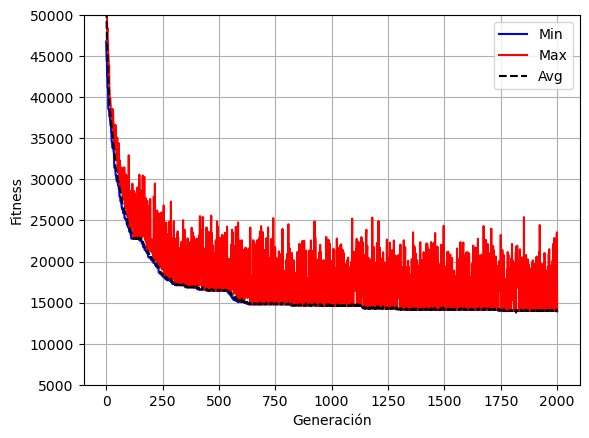

In [20]:
plot_evolucion(log)

In [21]:
log

[{'gen': 0,
  'nevals': 100,
  'avg': 52298.84,
  'std': 2050.604416848847,
  'min': 46803.0,
  'max': 57738.0},
 {'gen': 1,
  'nevals': 100,
  'avg': 50439.9,
  'std': 1947.3927929413726,
  'min': 45573.0,
  'max': 54278.0},
 {'gen': 2,
  'nevals': 100,
  'avg': 48767.74,
  'std': 1856.3106454470383,
  'min': 44543.0,
  'max': 52498.0},
 {'gen': 3,
  'nevals': 100,
  'avg': 47506.8,
  'std': 1482.7260704526645,
  'min': 44543.0,
  'max': 50523.0},
 {'gen': 4,
  'nevals': 100,
  'avg': 46380.23,
  'std': 1188.9579458921162,
  'min': 42598.0,
  'max': 49071.0},
 {'gen': 5,
  'nevals': 100,
  'avg': 45691.14,
  'std': 996.5673787556965,
  'min': 42598.0,
  'max': 47982.0},
 {'gen': 6,
  'nevals': 100,
  'avg': 44941.23,
  'std': 1083.5979499334612,
  'min': 41184.0,
  'max': 48372.0},
 {'gen': 7,
  'nevals': 100,
  'avg': 44340.04,
  'std': 1088.1115560456105,
  'min': 41184.0,
  'max': 46619.0},
 {'gen': 8,
  'nevals': 100,
  'avg': 43780.86,
  'std': 1149.7172262778356,
  'min': 41157.